# Atividade 2 - Transformações no Domínio Espacial e da Frequência
## Aluno: Vitor Fontenele - 1700778

### Imports

In [36]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

### Setup

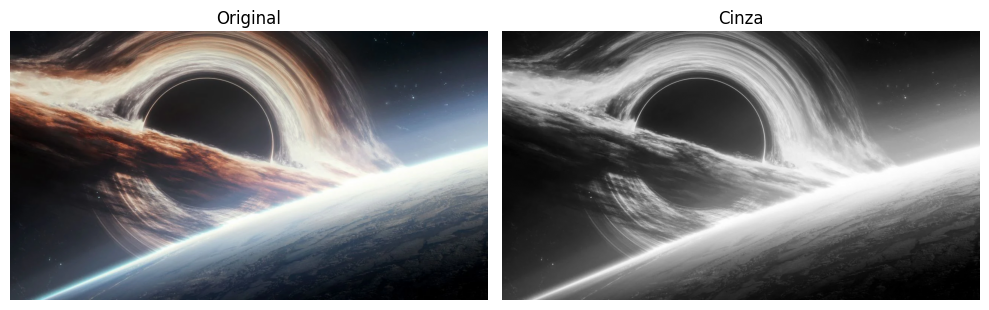

In [37]:
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

IMG_PATH = Path('gargantua.png') 
OUT_DIR = Path('outputs')

def load_image(path=IMG_PATH):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Imagem não encontrada: {path.resolve()}')
    bgr = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if bgr is None:
        raise ValueError(f'Não foi possível ler a imagem: {path.resolve()}')
    if bgr.ndim == 2: 
        return bgr
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def to_gray(img):
    if img.ndim == 2: return img
    return (0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]).astype(np.float32)

def save_image(filename, img, out_dir=OUT_DIR):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / filename
    arr = np.clip(img, 0, 255).astype(np.uint8)
    if arr.ndim == 3:
        arr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(out_path), arr)
    return out_path

def show_grid(images, titles, cols=3):
    n = len(images)
    rows = (n + cols - 1) // cols
    
    _, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    axes = axes.flatten() if n > 1 else [axes]
    
    for i in range(len(axes)):
        if i < n:
            axes[i].imshow(images[i], vmin=0, vmax=255)
            axes[i].set_title(titles[i])
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()
    
def initialize():
    img = load_image()
    img_gray = to_gray(img)
    save_image('gargantua_gray.png', img_gray, '.')
    show_grid([img, img_gray], ['Original', 'Cinza'], cols=2)
    
initialize()

## Questão 1 - Convolução

### Preparação para Convolução: Definição de filtros e função

In [38]:
kernels = {
    "h1": np.array([
        [ 0,  0, -1,  0,  0],
        [ 0, -1, -2, -1,  0],
        [-1, -2, 16, -2, -1],
        [ 0, -1, -2, -1,  0],
        [ 0,  0, -1,  0,  0]
    ], dtype=np.float32),
    
    "h2": (1/256) * np.array([
        [1,  4,  6,  4, 1],
        [4, 16, 24, 16, 4],
        [6, 24, 36, 24, 6],
        [4, 16, 24, 16, 4],
        [1,  4,  6,  4, 1]
    ], dtype=np.float32),
    
    "h3": np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float32),
    
    "h4": np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ], dtype=np.float32),
    
    "h5": np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ], dtype=np.float32),
    
    "h6": (1/9) * np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ], dtype=np.float32),
    
    "h7": np.array([
        [-1, -1,  2],
        [-1,  2, -1],
        [ 2, -1, -1]
    ], dtype=np.float32),
    
    "h8": np.array([
        [ 2, -1, -1],
        [-1,  2, -1],
        [-1, -1,  2]
    ], dtype=np.float32),
    
    "h9": (1/9) * np.eye(9),
    
    "h10": (1/8) * np.array([
        [-1, -1, -1, -1, -1],
        [-1,  2,  2,  2, -1],
        [-1,  2,  8,  2, -1],
        [-1,  2,  2,  2, -1],
        [-1, -1, -1, -1, -1]
    ], dtype=np.float32),
    
    "h11": np.array([
        [-1, -1,  0],
        [-1,  0,  1],
        [ 0,  1,  1]
    ], dtype=np.float32)
}

def convolution(imagem, filtro):
    i_h, i_w = imagem.shape
    f_h, f_w = filtro.shape
    
    pad_h, pad_w = f_h // 2, f_w // 2
    
    imagem_pad = np.pad(imagem, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    
    saida = np.zeros_like(imagem, dtype=np.float32)
    
    for i in range(i_h):
        for j in range(i_w):
            regiao = imagem_pad[i:i+f_h, j:j+f_w]
            
            saida[i, j] = np.sum(regiao * filtro)
            
    return saida

### Rodando

Aplicando h1...
Aplicando h2...
Aplicando h3...
Aplicando h4...
Aplicando h5...
Aplicando h6...
Aplicando h7...
Aplicando h8...
Aplicando h9...
Aplicando h10...
Aplicando h11...


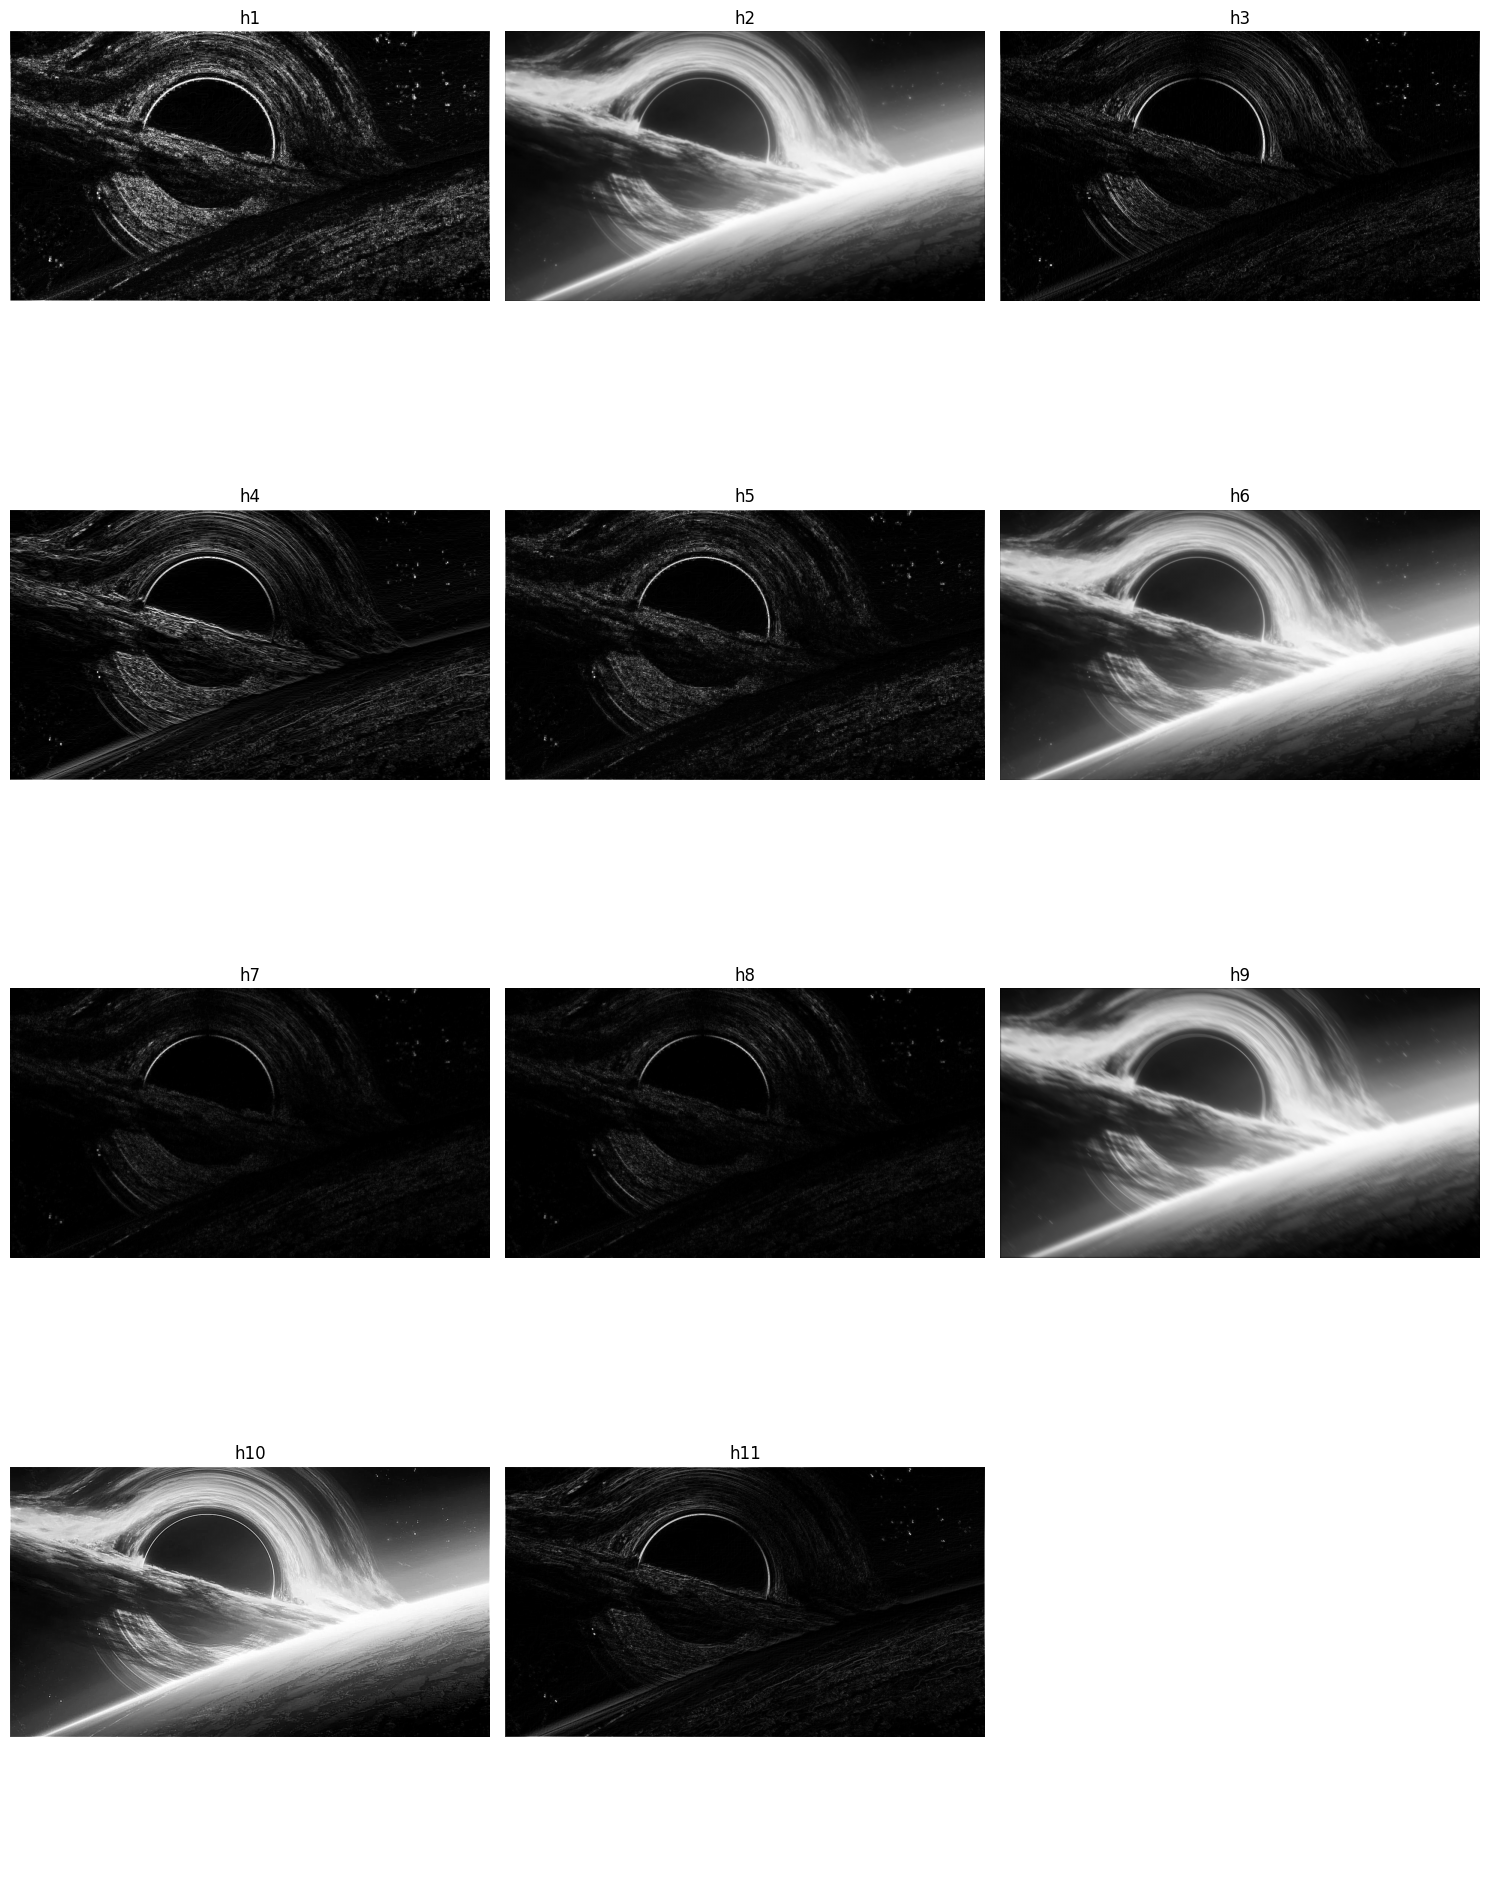

In [39]:

img_original = load_image('gargantua_gray.png')
img = to_gray(img_original)
resultados = []
titulos = []

for nome, filtro in kernels.items():
    print(f"Aplicando {nome}...")
    
    img_filtrada = convolution(img, filtro)
    
    img_visualizacao = np.abs(img_filtrada) 
    
    resultados.append(img_visualizacao)
    titulos.append(nome)
    
    save_image(f'resultado_{nome}.png', img_visualizacao)

show_grid(resultados, titulos)

## Questão 2 - FFT